# Lab 3: Control Flow for Data Cleaning

## Topic
Loops, Functions, and Error Handling in R

## Dataset
UCI Heart Disease Dataset

### Objectives
- Clean invalid resting blood pressure values
- Create a reusable BP-cleaning function using if-else
- Handle errors using tryCatch()
- Compare loop-based and vectorized cleaning
- Measure execution time
- Validate the cleaned dataset

In [1]:
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
download.file(url, "heart_disease.csv", mode = "wb")
print("Dataset downloaded successfully")

[1] "Dataset downloaded successfully"


In [5]:
column_names <- c(
  "age",
  "sex",
  "cp",
  "trestbps",
  "chol",
  "fbs",
  "restecg",
  "thalach",
  "exang",
  "oldpeak",
  "slope",
  "ca",
  "thal",
  "target"
)

heart_data <- read.csv(
  "heart_disease.csv",
  header = FALSE,
  col.names = column_names,
  na.strings = "?"
)

head(heart_data)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
6,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0


In [6]:
str(heart_data)

'data.frame':	303 obs. of  14 variables:
 $ age     : num  63 67 67 37 41 56 62 57 63 53 ...
 $ sex     : num  1 1 1 1 0 1 0 0 1 1 ...
 $ cp      : num  1 4 4 3 2 2 4 4 4 4 ...
 $ trestbps: num  145 160 120 130 130 120 140 120 130 140 ...
 $ chol    : num  233 286 229 250 204 236 268 354 254 203 ...
 $ fbs     : num  1 0 0 0 0 0 0 0 0 1 ...
 $ restecg : num  2 2 2 0 2 0 2 0 2 2 ...
 $ thalach : num  150 108 129 187 172 178 160 163 147 155 ...
 $ exang   : num  0 1 1 0 0 0 0 1 0 1 ...
 $ oldpeak : num  2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 1.4 3.1 ...
 $ slope   : num  3 2 2 3 1 1 3 1 2 3 ...
 $ ca      : num  0 3 2 0 0 0 2 0 1 0 ...
 $ thal    : num  6 3 7 3 3 3 3 3 7 7 ...
 $ target  : int  0 2 1 0 0 0 3 0 2 1 ...


In [7]:
summary(heart_data$trestbps)
cat("Minimum BP:", min(heart_data$trestbps, na.rm = TRUE), "\n")
cat("Maximum BP:", max(heart_data$trestbps, na.rm = TRUE), "\n")

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   94.0   120.0   130.0   131.7   140.0   200.0 

Minimum BP: 94 
Maximum BP: 200 


In [8]:
set.seed(123)

dirty_heart_data <- heart_data
dirty_heart_data$trestbps[c(5, 15, 25)] <- -20
dirty_heart_data$trestbps[c(35, 45)] <- NA
dirty_heart_data$trestbps[c(55, 65, 75)] <- c(320, 350, 400)

head(dirty_heart_data$trestbps, 80)

[1] 145 160 120 130 -20 120 140 120 130 140 140 140 130 120 -20 150 110 140 130
[20] 130 110 150 120 132 -20 120 120 150 150 110 140 117 140 135  NA 140 120 150
[39] 132 150 150 140 160 150  NA 112 110 150 140 130 105 120 112 130 320 124 140
[58] 110 125 125 130 142 128 135 350 145 140 150 170 150 155 125 120 110 400 160
[77] 125 140 130 150

In [9]:
cat("Negative BP values:", sum(dirty_heart_data$trestbps < 0, na.rm = TRUE), "\n")
cat("Missing BP values:", sum(is.na(dirty_heart_data$trestbps)), "\n")
cat("BP values greater than 300:", sum(dirty_heart_data$trestbps > 300, na.rm = TRUE), "\n")

Negative BP values: 3 
Missing BP values: 2 
BP values greater than 300: 3 


In [10]:
clean_bp <- function(bp) {

  if (is.na(bp)) {
    return(NA)
  } else if (bp < 0) {
    return(NA)
  } else if (bp > 250) {
    return(250)
  } else {
    return(bp)
  }
}

In [11]:
cleaned_heart_data <- dirty_heart_data

cleaned_heart_data$trestbps <- sapply(
  cleaned_heart_data$trestbps,
  clean_bp
)

head(cleaned_heart_data$trestbps, 80)

[1] 145 160 120 130  NA 120 140 120 130 140 140 140 130 120  NA 150 110 140 130
[20] 130 110 150 120 132  NA 120 120 150 150 110 140 117 140 135  NA 140 120 150
[39] 132 150 150 140 160 150  NA 112 110 150 140 130 105 120 112 130 250 124 140
[58] 110 125 125 130 142 128 135 250 145 140 150 170 150 155 125 120 110 250 160
[77] 125 140 130 150

In [12]:
safe_mean_bp <- function(bp) {
  tryCatch({
    if (all(is.na(bp))) {
      stop("All BP values are missing.")
    }
    mean(bp, na.rm = TRUE)
  }, warning = function(w) {
    message("Warning while calculating mean: ", w$message)
    NA
  }, error = function(e) {
    message("Error while calculating mean BP: ", e$message)
    NA
  })
}

In [14]:
mean_bp <- safe_mean_bp(cleaned_heart_data$trestbps)
cat("Mean BP:", mean_bp, "\n")

Mean BP: 132.8859 


In [15]:
safe_ratio <- function(chol, bp) {
  tryCatch({
    if (is.na(chol) || is.na(bp)) {
      stop("Cholesterol or BP is missing.")
    }
    if (bp == 0) {
      stop("Cannot divide by zero.")
    }
    if (bp < 0) {
      stop("BP value is invalid.")
    }
    chol / bp
  }, warning = function(w) {
    message("Warning: ", w$message)
    NA
  }, error = function(e) {
    message("Invalid ratio: ", e$message)
    NA
  })
}

In [16]:
cleaned_heart_data$chol_bp_ratio <- mapply(
  safe_ratio,
  cleaned_heart_data$chol,
  cleaned_heart_data$trestbps
)
head(cleaned_heart_data[, c("chol", "trestbps", "chol_bp_ratio")])

Invalid ratio: Cholesterol or BP is missing.

Invalid ratio: Cholesterol or BP is missing.

Invalid ratio: Cholesterol or BP is missing.

Invalid ratio: Cholesterol or BP is missing.

Invalid ratio: Cholesterol or BP is missing.



,chol,trestbps,chol_bp_ratio
,<dbl>,<dbl>,<dbl>
1,233,145,1.606897
2,286,160,1.787500
3,229,120,1.908333
4,250,130,1.923077
5,204,NA,NA
6,236,120,1.966667


In [18]:
loop_data <- dirty_heart_data

In [19]:
start_loop <- Sys.time()

for (i in 1:nrow(loop_data)) {
  bp <- loop_data$trestbps[i]
  if (is.na(bp)) {
    loop_data$trestbps[i] <- NA

  } else if (bp < 0) {
    loop_data$trestbps[i] <- NA

  } else if (bp > 250) {
    loop_data$trestbps[i] <- 250
  }
}

end_loop <- Sys.time()
loop_time <- end_loop - start_loop
loop_time

Time difference of 0.01138282 secs

In [20]:
vector_data <- dirty_heart_data

In [21]:
start_vector <- Sys.time()
vector_data$trestbps[
  vector_data$trestbps < 0
] <- NA
vector_data$trestbps[
  vector_data$trestbps > 250
] <- 250

end_vector <- Sys.time()
vector_time <- end_vector - start_vector
vector_time

Time difference of 0.002475023 secs

In [22]:
identical(loop_data$trestbps, vector_data$trestbps)

[1] TRUE

In [23]:
comparison <- data.frame(
  Method = c("For Loop", "Vectorized"),
  Execution_Time = c(
    as.numeric(loop_time),
    as.numeric(vector_time)
  )
)

comparison

Method,Execution_Time
<chr>,<dbl>
For Loop,0.011382818
Vectorized,0.002475023


In [24]:
missing_bp <- sum(is.na(cleaned_heart_data$trestbps))
cat("Missing BP values:", missing_bp, "\n")


Missing BP values: 5 


In [25]:
cat("Minimum BP:", min(cleaned_heart_data$trestbps, na.rm = TRUE), "\n")
cat("Maximum BP:", max(cleaned_heart_data$trestbps, na.rm = TRUE), "\n")

Minimum BP: 94 
Maximum BP: 250 


In [26]:
cat("Mean BP:", mean(cleaned_heart_data$trestbps, na.rm = TRUE), "\n")
cat("Median BP:", median(cleaned_heart_data$trestbps, na.rm = TRUE), "\n")

Mean BP: 132.8859 
Median BP: 130 


In [27]:
negative_remaining <- sum(cleaned_heart_data$trestbps < 0, na.rm = TRUE)

above_250_remaining <- sum(cleaned_heart_data$trestbps > 250, na.rm = TRUE)

cat("Negative BP values remaining:", negative_remaining, "\n")
cat("BP values > 250 remaining:", above_250_remaining, "\n")

Negative BP values remaining: 0 
BP values > 250 remaining: 0 


In [28]:
write.csv(cleaned_heart_data, "cleaned_heart_data.csv", row.names = FALSE)
print("cleaned_heart_data.csv created successfully")

[1] "cleaned_heart_data.csv created successfully"


## Conclusion

The Heart Disease dataset was cleaned using a custom BP-cleaning function based on if-else conditions. Negative blood-pressure values were converted to NA, values greater than 250 mmHg were capped at 250, and valid values were retained.

The tryCatch() function was used to safely calculate the mean blood pressure and cholesterol-to-BP ratio while handling missing, zero, and invalid denominator values.

Both loop-based and vectorized approaches were implemented and their execution times were compared. The vectorized approach is generally more efficient in R because operations are performed directly on vectors rather than processing each row individually.

Finally, the cleaned dataset was validated by checking missing values, minimum, maximum, mean, median, and the presence of remaining invalid BP values.

# Lab 4: Advanced Missing Data Handling

## Topic
NA, NULL, NaN, Missing-Value Detection and Imputation

## Dataset
UCI Adult / Census Income Dataset

### Objectives
- Identify NA, NULL, NaN and blank strings
- Identify impossible numeric values
- Treat missing and invalid observations
- Implement median imputation
- Analyze missingness before and after cleaning
- Visualize missingness
- Validate the cleaned dataset

In [29]:
install.packages(c("dplyr", "naniar", "skimr"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’




In [30]:
library(dplyr)
library(naniar)
library(skimr)


Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




In [31]:
adult_url <- "https://archive.ics.uci.edu/static/public/2/adult.zip"

download.file(adult_url,"adult.zip",mode = "wb")

unzip("adult.zip")

cat("Files extracted:\n")
print(list.files())

Files extracted:
[1] "adult.data"             "adult.names"            "adult.test"            
[4] "adult.zip"              "cleaned_heart_data.csv" "heart_disease.csv"     
[7] "Index"                  "old.adult.names"        "sample_data"           


In [33]:
adult_data <- read.csv("adult.data", header = FALSE)
adult_data <- adult_data[, 1:14]

colnames(adult_data) <- c(
  "age",
  "workclass",
  "fnlwgt",
  "education",
  "education_num",
  "marital_status",
  "occupation",
  "relationship",
  "race",
  "sex",
  "capital_gain",
  "capital_loss",
  "hours_per_week",
  "income"
)

cat("Rows:", nrow(adult_data), "\n")
cat("Columns:", ncol(adult_data), "\n")

head(adult_data)

Rows: 32561 
Columns: 14 


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States


In [37]:
adult_data <- read.table(
  "adult.data",
  header = FALSE,
  sep = ",",
  strip.white = TRUE,
  quote = "",
  comment.char = "",
  stringsAsFactors = FALSE
)

adult_columns <- c(
  "age",
  "workclass",
  "fnlwgt",
  "education",
  "education_num",
  "marital_status",
  "occupation",
  "relationship",
  "race",
  "sex",
  "capital_gain",
  "capital_loss",
  "hours_per_week",
  "native_country", # This should be native_country
  "income" # This is the 15th column
)

colnames(adult_data) <- adult_columns

cat("Rows:", nrow(adult_data), "\n")
cat("Columns:", ncol(adult_data), "\n")

head(adult_data)

Rows: 32561 
Columns: 15 


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [36]:
str(adult_data)

'data.frame':	32561 obs. of  15 variables:
 $ age           : int  39 50 38 53 28 37 49 52 31 42 ...
 $ workclass     : chr  "State-gov" "Self-emp-not-inc" "Private" "Private" ...
 $ fnlwgt        : int  77516 83311 215646 234721 338409 284582 160187 209642 45781 159449 ...
 $ education     : chr  "Bachelors" "Bachelors" "HS-grad" "11th" ...
 $ education_num : int  13 13 9 7 13 14 5 9 14 13 ...
 $ marital_status: chr  "Never-married" "Married-civ-spouse" "Divorced" "Married-civ-spouse" ...
 $ occupation    : chr  "Adm-clerical" "Exec-managerial" "Handlers-cleaners" "Handlers-cleaners" ...
 $ relationship  : chr  "Not-in-family" "Husband" "Not-in-family" "Husband" ...
 $ race          : chr  "White" "White" "White" "Black" ...
 $ sex           : chr  "Male" "Male" "Male" "Male" ...
 $ capital_gain  : int  2174 0 0 0 0 0 0 0 14084 5178 ...
 $ capital_loss  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hours_per_week: int  40 13 40 40 40 40 16 45 50 40 ...
 $ income        : chr  "United-States" "Uni

In [38]:
set.seed(123)
dirty_adult_data <- adult_data
# Introduce NA values
dirty_adult_data$age[c(10, 20)] <- NA
# Introduce blank strings
dirty_adult_data$workclass[c(30, 40)] <- ""
# Introduce NaN
dirty_adult_data$education_num[c(50, 60)] <- NaN
# Introduce impossible age
dirty_adult_data$age[c(70, 80)] <- 999
head(dirty_adult_data, 100)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<dbl>,<chr>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
7,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
8,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
9,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K


In [39]:
is.na(dirty_adult_data$age[10])
is.nan(dirty_adult_data$education_num[50])
x <- NULL
print(x)
print(is.null(x))

[1] TRUE

[1] TRUE

NULL
[1] TRUE


In [40]:
x_na <- NA

print(x_na)
print(is.na(x_na))

print(is.null(x_na))

[1] NA
[1] TRUE
[1] FALSE


In [41]:
blank_workclass <- dirty_adult_data$workclass == ""
sum(blank_workclass, na.rm = TRUE)

[1] 2

In [42]:
sum(dirty_adult_data$age == 999, na.rm = TRUE)

[1] 2

In [43]:
miss_var_summary(dirty_adult_data)

variable,n_miss,pct_miss
<chr>,<int>,<num>
age,2,0.006[4m1[24m[4m4[24m
education_num,2,0.006[4m1[24m[4m4[24m
workclass,0,0
fnlwgt,0,0
education,0,0
marital_status,0,0
occupation,0,0
relationship,0,0
race,0,0


In [44]:
dirty_adult_data$age[dirty_adult_data$age == 999] <- NA
dirty_adult_data$workclass[dirty_adult_data$workclass == ""] <- "Unknown"
dirty_adult_data <- dirty_adult_data[!is.nan(dirty_adult_data$education_num),]

In [45]:
median_impute <- function(x) {
  if (!is.numeric(x)) {
    stop("Input must be numeric.")
  }
  missing <- is.na(x) | is.nan(x)
  if (all(missing)) {
    stop("All values are missing. Cannot calculate median.")
  }
  median_value <- median(
    x[!missing],
    na.rm = TRUE
  )
  x[missing] <- median_value
  return(x)
}

In [46]:
numeric_columns <- c(
  "age",
  "fnlwgt",
  "education_num",
  "capital_gain",
  "capital_loss",
  "hours_per_week"
)

for (col in numeric_columns) {
  dirty_adult_data[[col]] <- median_impute(
    dirty_adult_data[[col]]
  )
}

In [47]:
complete_rows <- complete.cases(dirty_adult_data)

cat("Complete observations:",sum(complete_rows),"\n")
cat("Incomplete observations:",sum(!complete_rows),"\n")

Complete observations: 32559 
Incomplete observations: 0 


In [48]:
complete_adult_data <- dirty_adult_data[complete_rows,]
head(complete_adult_data)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<dbl>,<chr>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [49]:
before_cleaning <- dirty_adult_data

In [50]:
# Save a copy before treatment
dirty_before_cleaning <- adult_data

dirty_before_cleaning$age[c(10, 20)] <- NA
dirty_before_cleaning$workclass[c(30, 40)] <- ""
dirty_before_cleaning$education_num[c(50, 60)] <- NaN
dirty_before_cleaning$age[c(70, 80)] <- 999

In [51]:
missing_before <- sum(is.na(dirty_before_cleaning))

missing_after <- sum(is.na(dirty_adult_data))

cat("Missing values before cleaning:", missing_before, "\n")
cat("Missing values after cleaning:", missing_after, "\n")

Missing values before cleaning: 4 
Missing values after cleaning: 0 


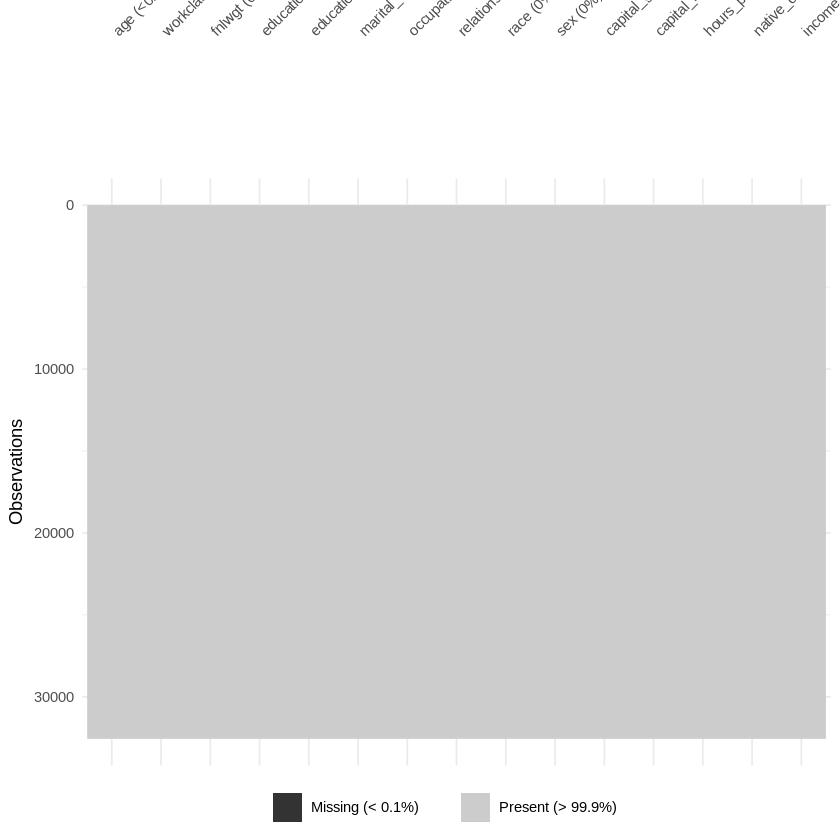

In [52]:
vis_miss(dirty_before_cleaning)

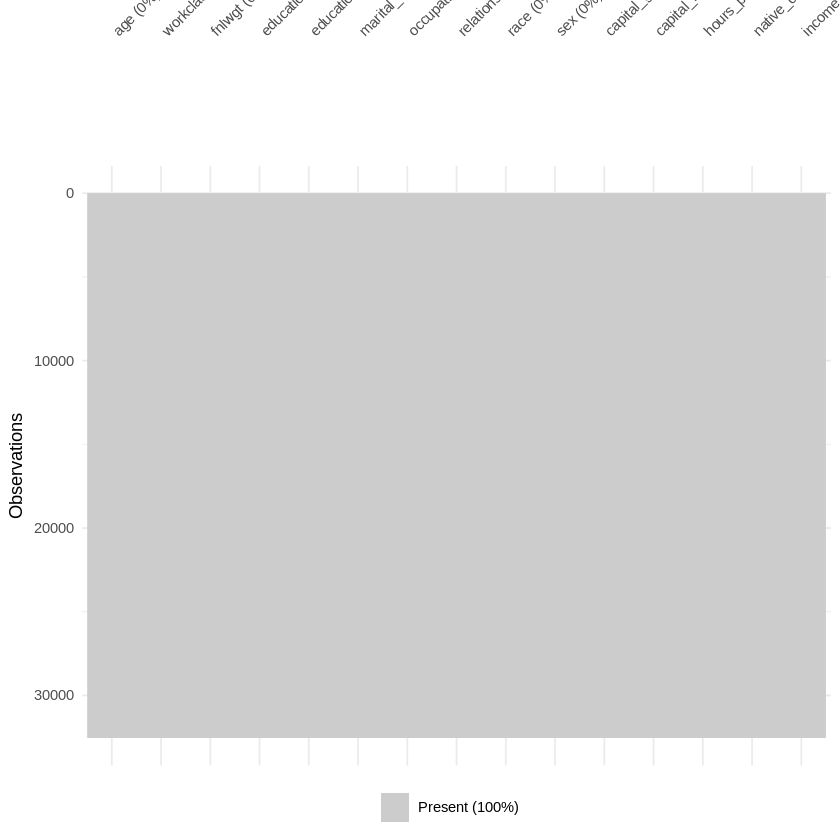

In [53]:
vis_miss(dirty_adult_data)


In [54]:
write.csv(dirty_adult_data,"cleaned_adult_data.csv",row.names = FALSE)
print("cleaned_adult_data.csv created successfully")

[1] "cleaned_adult_data.csv created successfully"


## Conclusion

The Adult dataset was examined for different forms of missing and invalid data. NA, NaN, NULL, blank strings, and impossible numeric values were demonstrated and differentiated.

Invalid age values such as 999 were converted to NA, blank categorical values were replaced with "Unknown", and missing numeric values were treated using median imputation. A custom median-imputation function was created and applied to selected numeric variables.

The complete.cases() function was used to identify complete and incomplete observations. Missingness was analyzed before and after cleaning using naniar, and missing-value patterns were visualized using vis_miss(). The cleaned dataset was finally validated using skimr::skim() and exported as cleaned_adult_data.csv.